# Sydney Housing Price Prediction and Decision Support System

**Suburbs:** Mosman, Parramatta, Campbelltown
**Data source:** domain.com.au (sold listings)
**Scope of this notebook:** Part 1 (Problem & Data), Part 2 (Data Understanding & Feature Engineering), Part 3 (Model Development & Evaluation), Part 4 (Prediction Failures). Part 5 and 6 (LLM vs human comparison and the deployed app)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Part 1: Problem Definition and Data Collection

### Discussion

The goal of this project is to predict the sale price of a house using its features (suburb, bedrooms, size and so on). This is useful for a real estate agency because it gives buyers and sellers a data based starting point for what a property might be worth.

We picked three Sydney suburbs that are quite different from each other:

- **Mosman**  an expensive harbourside suburb close to the CBD (8 km away).
- **Parramatta**  a large, growing suburb further out (24 km away), with a mix of older houses and new high density unit developments.
- **Campbelltown**  an outer-suburban area (55 km away) with more affordable family housing.

In [2]:
raw_data = pd.read_csv('raw_property_data.csv')
clean_data = pd.read_csv('cleaned_property_data.csv')

print('RAW FILE: raw_property_data.csv | shape:', raw_data.shape)
print('CLEANED FILE: cleaned_property_data.csv | shape:', clean_data.shape)
print()
print('Raw columns:', list(raw_data.columns))
print()
print('Cleaned columns:', list(clean_data.columns))

RAW FILE: raw_property_data.csv | shape: (105, 17)
CLEANED FILE: cleaned_property_data.csv | shape: (105, 20)

Raw columns: ['address', 'suburb', 'postcode', 'sale_date', 'property_type', 'sale_price', 'bedrooms', 'bathrooms', 'car_spaces', 'land_size_sqm', 'floor_area_sqm', 'year_built', 'distance_to_cbd_km', 'notes', 'source', 'source_url', 'collection_date']

Cleaned columns: ['address', 'suburb', 'postcode', 'sale_date', 'property_type', 'sale_price', 'bedrooms', 'bathrooms', 'car_spaces', 'land_size_sqm', 'floor_area_sqm', 'year_built', 'distance_to_cbd_km', 'notes', 'source', 'source_url', 'collection_date', 'atypical_sale', 'type_ambiguous', 'tenanted_sale']


### Result

Both files have **105 rows** (properties). The raw file has **17 columns**, and the cleaned file has **20 columns**, the cleaned file has 3 extra columns (`atypical_sale`, `type_ambiguous`, `tenanted_sale`) that were added during cleaning to flag unusual sales. We explain these below.


In [3]:
print('Data types (cleaned file)')
print(clean_data.dtypes)
print()
print('- Missing values (cleaned file) -')
print(clean_data.isnull().sum())
print()
print('- Duplicate rows -')
print('Raw duplicate rows:', raw_data.duplicated().sum())
print('Cleaned duplicate rows:', clean_data.duplicated().sum())
print('Duplicate addresses:', clean_data.duplicated(subset=['address']).sum())


Data types (cleaned file)
address                object
suburb                 object
postcode                int64
sale_date              object
property_type          object
sale_price              int64
bedrooms                int64
bathrooms               int64
car_spaces              int64
land_size_sqm         float64
floor_area_sqm        float64
year_built            float64
distance_to_cbd_km      int64
notes                  object
source                 object
source_url             object
collection_date        object
atypical_sale            bool
type_ambiguous           bool
tenanted_sale            bool
dtype: object

- Missing values (cleaned file) -
address                 0
suburb                  0
postcode                0
sale_date               0
property_type           0
sale_price              0
bedrooms                0
bathrooms               0
car_spaces              0
land_size_sqm          60
floor_area_sqm         85
year_built            105
distance_to_c

### Result

There are **no duplicate rows and no duplicate addresses** in either file, so every property is a separate sale.

Missing values only show up in three columns:

- `land_size_sqm`  missing for 60 of 105 properties (mostly units, which do not have their own land size)
- `floor_area_sqm`  missing for 85 of 105 properties (most listings do not state internal floor area)
- `year_built`  missing for **all 105** properties (Domain listings almost never state this, so we cannot use this column at all)

In [4]:
print('- Properties per suburb -')
print(clean_data['suburb'].value_counts())
print()
print('- Properties per property type -')
print(clean_data['property_type'].value_counts())
print()
print('- Sale price summary (target variable) -')
print(clean_data['sale_price'].describe().round(0))

- Properties per suburb -
suburb
Mosman          35
Parramatta      35
Campbelltown    35
Name: count, dtype: int64

- Properties per property type -
property_type
Unit         38
House        35
Townhouse    32
Name: count, dtype: int64

- Sale price summary (target variable) -
count        105.0
mean     1499516.0
std      1298219.0
min       320000.0
25%       705000.0
50%       980000.0
75%      1785000.0
max      7600000.0
Name: sale_price, dtype: float64


### Result

The dataset has exactly **35 properties per suburb** (105 total), so it easily satisfies the assignment's minimum of 100 properties overall and 30 per suburb.

The target variable is `sale_price`. Prices range from 320K dollars (a small unit), to 7.6M dollar (a large Mosman house), with a median of \$980,000. This is a very wide range, and it is heavily driven by suburb  we look at this properly in Part 2.

**Checking Part 1 requirements:**
- At least 100 sold properties (we have 105)
- At least 30 properties per suburb (we have 35/35/35)
- Three substantially different housing markets (confirmed below by price and distance)
- Sale price collected as the prediction target
- A broad range of property features collected (bedrooms, bathrooms, car spaces, land size, floor area, distance to CBD, property type)


In [5]:
print('- Median price and distance to CBD by suburb -')
summary =clean_data.groupby('suburb').agg(
    median_price=('sale_price','median'),
    mean_price=('sale_price','mean'),
    distance_to_cbd_km=('distance_to_cbd_km','first'),
    n_properties=('sale_price','count')
).round(0)
print(summary)

- Median price and distance to CBD by suburb -
              median_price  mean_price  distance_to_cbd_km  n_properties
suburb                                                                  
Campbelltown      772500.0    802447.0                  55            35
Mosman           2260000.0   2558286.0                   8            35
Parramatta       1068000.0   1137814.0                  24            35


### Result

The three suburbs really are different markets

- **Mosman** closest to the CBD (8 km) but by far the most expensive, with a median price several times higher than Campbelltown.
- **Parramatta** a middle ground suburb (24 km out) with mid range prices.
- **Campbelltown** furthest from the CBD (55 km) and the cheapest of the three.

The three suburbs show a clear difference in price and distance from the CBD. However, distance is the same for every property within a suburb, so
it mainly represents the location rather than the effect of distance itself.

### Raw data vs Cleaned data

**Raw data** this is exactly what was manually collected from domain.com.au sold listings one row per property, with a text version of the sale date (e.g. "12 Sep 2026") and no review flags.

**Cleaned data** starts from the raw data and adds:
1. `sale_date` converted to a proper date format (e.g. "2026-09-12") instead of text, so it can be used in calculations.
2. Three review flags added after manually reading each listing's description:
    `atypical_sale` (13 properties) — sales that are not a typical "buy the home as is" purchase, e.g. properties marketed mainly for their redevelopment/subdivision potential, or a dual occupancy sale.
    `type_ambiguous` (7 properties) — cases where Domain's category (House/Unit/Townhouse) did not clearly match the listing description (e.g. a "terrace" labelled as a House).
    `tenanted_sale` (3 properties) — sold with a tenant in place, which can sell for slightly different prices than a vacant property.

No rows or values were deleted — the cleaning only added information.

In [6]:
print('Example of a flagged atypical sale (from the notes written during data collection):')
example = clean_data[clean_data['atypical_sale']].iloc[0]
print(example[['address','suburb','property_type','sale_price','notes']])

Example of a flagged atypical sale (from the notes written during data collection):
address             1404/1-3 Valentine Avenue, Parramatta NSW 2150
suburb                                                  Parramatta
property_type                                                 Unit
sale_price                                                  320000
notes            Price notably below suburb median ($492.5k for...
Name: 12, dtype: object


### Result

This example shows why the flag was needed: the notes explain that the price likely reflects development potential rather than a typical home purchase. Keeping a record of why a sale looks unusual (instead of just deleting it) makes the dataset more honest and lets us investigate its effect later, rather than quietly losing information.

### Dataset quality, limitations and bias

A few honest limitations of this dataset:

- **Small sample size.** 35 properties per suburb is enough to satisfy the assignment, but it is still small for machine learning — a handful of unusual sales can have a noticeable effect on results.
- **Missing size information.** As shown above, `floor_area_sqm` and `land_size_sqm` are missing for a large share of properties, and `year_built` is missing for all of them. This limits how much the model can learn about the physical size and age of a property.
- **Manual, listing based collection.** All data came from reading individual Domain listings by hand. This is more accurate than scraping in some ways (we could read and flag odd cases), but it is also slower and means a human judgement call was involved in property-type classification for a handful of listings (see `type_ambiguous`).
- **Possible selection bias.** We only used properties that had a complete listing on Domain at the time of collection private/off-market sales, or sales with very little advertising, are not represented.

## Part 2: Data Understanding and Feature Engineering

### Discussion

Before building any model, we need to understand what the data actually looks like. We will look at the price distribution, how prices differ by suburb and property type, how prices have moved over time, and how a few key numeric features relate to price. We will also look for outliers.


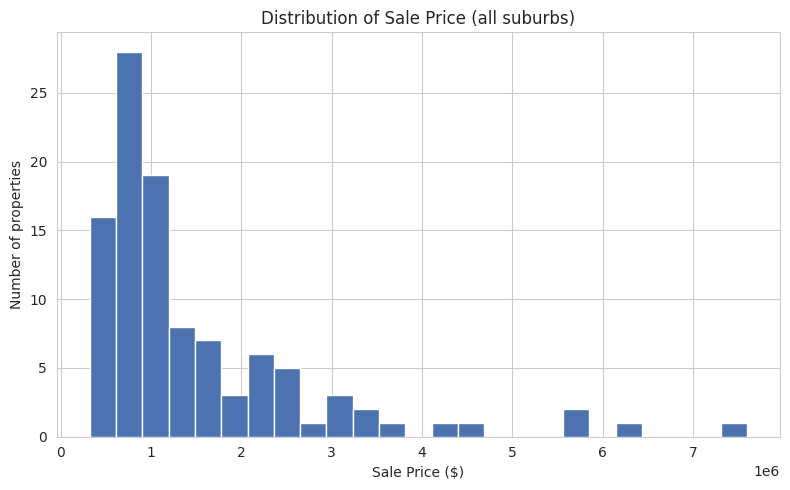

Skewness: 2.41


In [7]:
plt.figure(figsize=(8,5))
plt.hist(clean_data['sale_price'], bins=25, color='#4C72B0', edgecolor='white')
plt.title('Distribution of Sale Price (all suburbs)')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of properties')
plt.tight_layout()
plt.show()

print('Skewness:', round(clean_data['sale_price'].skew(), 2))

### Result

The price distribution is heavily **right-skewed** — most properties sell under 1.5 million, but a small number of expensive Mosman houses stretch the tail out to \$7.6 million. The skewness value confirms this (a value well above 0 means a long tail to the right).

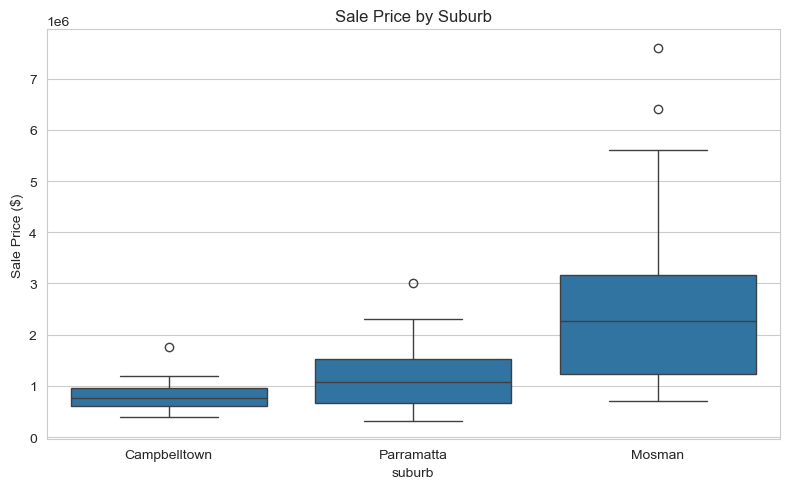

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(data=clean_data, x='suburb', y='sale_price', order=['Campbelltown','Parramatta','Mosman'])
plt.title('Sale Price by Suburb')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

### Result

The boxplot confirms what we already saw in the summary table: **Mosman is far more expensive** than Parramatta and Campbelltown, and it also has the widest spread of prices (from expensive units to very expensive houses). Campbelltown has the lowest and most tightly clustered prices. Suburb is clearly a major driver of price.


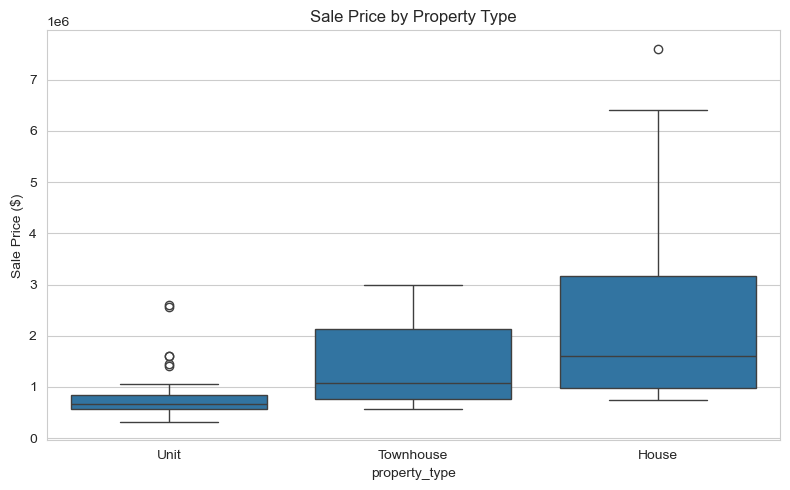

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(data=clean_data, x='property_type', y='sale_price', order=['Unit','Townhouse','House'])
plt.title('Sale Price by Property Type')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

### Result

Prices increase in a clear order: **Units are cheapest, Townhouses are in the middle, Houses are the most expensive.** This makes sense — houses usually come with more land and more space than units.


                 median  count
sale_quarter                  
2024Q3         565000.0      1
2025Q1        2525000.0      5
2025Q2         710000.0      1
2025Q3        1771000.0      5
2025Q4         640000.0      1
2026Q1        1145750.0      8
2026Q2        2152500.0     28
2026Q3         761250.0     56


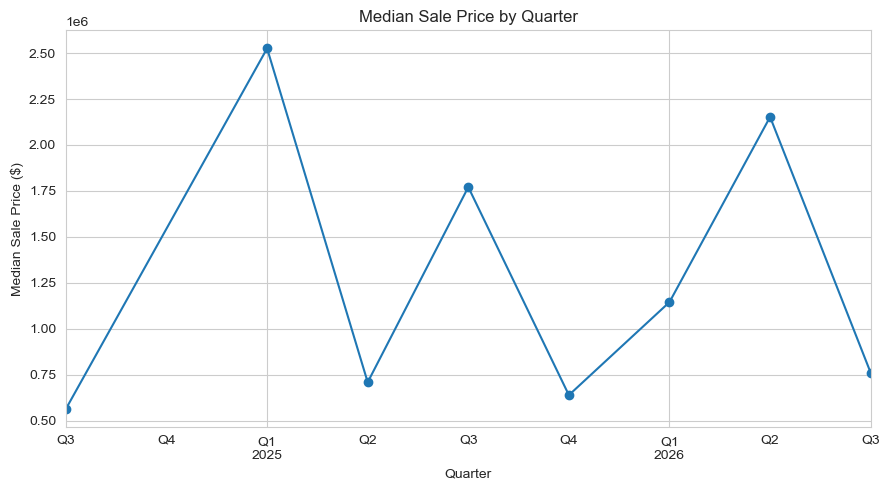

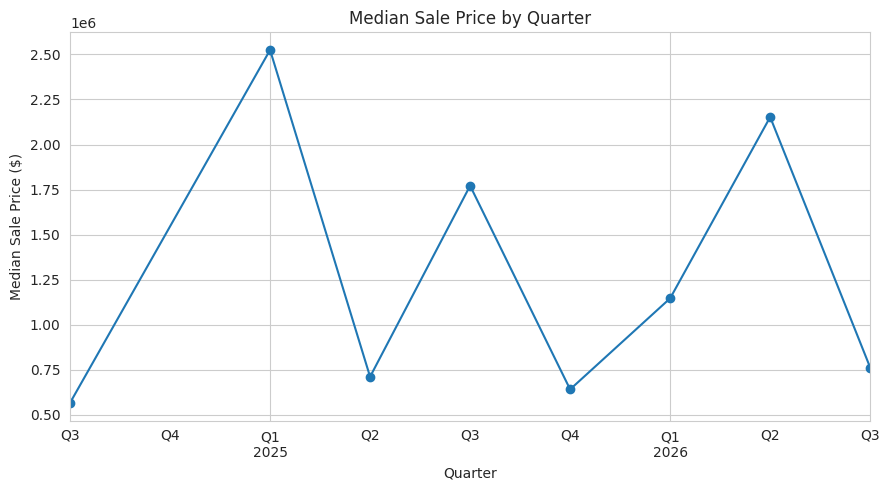

In [8]:
clean_data['sale_date'] = pd.to_datetime(clean_data['sale_date'])
clean_data['sale_quarter'] = clean_data['sale_date'].dt.to_period('Q')

quarterly_median = clean_data.groupby('sale_quarter')['sale_price'].agg(['median','count'])
print(quarterly_median)

plt.figure(figsize=(9,5))
quarterly_median['median'].plot(marker='o')
plt.title('Median Sale Price by Quarter')
plt.ylabel('Median Sale Price ($)')
plt.xlabel('Quarter')
plt.tight_layout()
plt.show()

### Result

This plot should be read carefully. Most of our properties (84 out of 105) were sold in the last two quarters (2026 Q2 and Q3) — the earlier quarters only have a handful of sales each. So the "trend" early in the chart is based on very few properties and is not reliable. We do not have enough spread across time to draw strong conclusions about price growth this is a real limitation of the dataset (see Part 1) rather than a modelling problem.

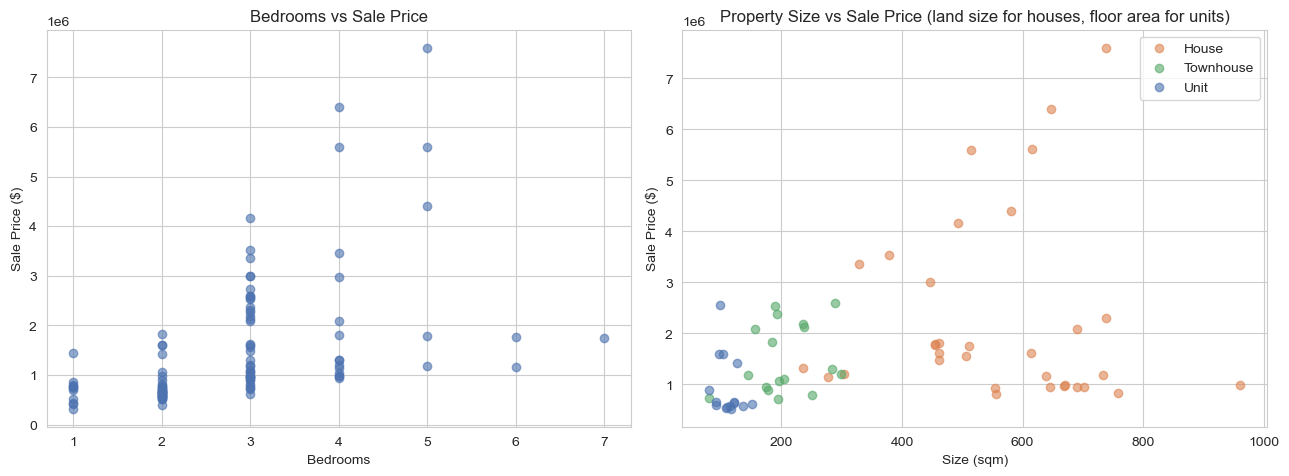

Correlation with sale_price:
sale_price            1.000000
bedrooms              0.502708
bathrooms             0.339331
car_spaces            0.155024
land_size_sqm         0.142494
floor_area_sqm        0.057453
distance_to_cbd_km   -0.509747
Name: sale_price, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2,figsize=(13,5))

axes[0].scatter(clean_data['bedrooms'], clean_data['sale_price'],alpha=0.6, color='#4C72B0')
axes[0].set_title('Bedrooms vs Sale Price')
axes[0].set_xlabel('Bedrooms')
axes[0].set_ylabel('Sale Price ($)')

for ptype, colour in zip(['House','Townhouse','Unit'], ['#DD8452','#55A868','#4C72B0']):
    subset =clean_data[clean_data['property_type']==ptype]
    size_col= subset['floor_area_sqm'].fillna(subset['land_size_sqm'])
    axes[1].scatter(size_col, subset['sale_price'],alpha=0.6, label=ptype,color=colour)
axes[1].set_title('Property Size vs Sale Price (land size for houses, floor area for units)')
axes[1].set_xlabel('Size (sqm)')
axes[1].set_ylabel('Sale Price ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Correlation with sale_price:')
print(clean_data[['bedrooms','bathrooms','car_spaces','land_size_sqm','floor_area_sqm','distance_to_cbd_km','sale_price']].corr()['sale_price'].sort_values(ascending=False))

### Result

**Bedrooms** has a fairly clear positive relationship with price (correlation of about 0.50)  more bedrooms generally means a higher price, though there is a lot of spread.

**Size** is positively related to price too, but more weakly on its own  this is because land size and floor area mean different things for different property types so the two need to be read separately, not as 1 clean line.

**Distance to CBD** has the strongest correlation of all (about -0.51), but as noted earlier, this is just standing in for suburb, since every property in a suburb has the same distance value.

In [13]:
# Unusual observations or potential outliers
price_iqr_outliers =[]
for suburb in clean_data['suburb'].unique():
    sub =clean_data[clean_data['suburb'] ==suburb]
    q1, q3= sub['sale_price'].quantile([0.25, 0.75])
    iqr =q3-q1
    low, high =q1 -1.5*iqr,q3 +1.5*iqr
    outliers= sub[(sub['sale_price'] < low) | (sub['sale_price'] >high)]
    price_iqr_outliers.append(outliers)

outliers_df =pd.concat(price_iqr_outliers)
print("Number of price outliers (IQR method, within suburb):",len(outliers_df))
print(outliers_df[["address","suburb","property_type","sale_price"]].to_string(index=False))

Number of price outliers (IQR method, within suburb): 4
                                        address       suburb property_type  sale_price
                 2 Dugald Road, Mosman NSW 2088       Mosman         House     7600000
             5 Euryalus Street, Mosman NSW 2088       Mosman         House     6400000
            14 Ross Street, Parramatta NSW 2150   Parramatta         House     3000000
28 & 28A Westview Street, Campbelltown NSW 2560 Campbelltown         House     1750000


### Result

Using the standard IQR rule *within each suburb* (so a high Mosman price is not unfairly flagged just for being a high price in general), we find **4 outliers**. Looking at the notes we wrote during data collection:

- The **\$7.6M Mosman house** and the **\$6.4M Mosman house** both look like genuine, very large/expensive properties — not data errors.
- The **\$3M Parramatta property** is actually a mixed residential + commercial freehold, so it is not a normal house sale at all its price includes a commercial component.
- The **\$1.75M Campbelltown property** is a dual occupancy sale (two dwellings — a "28 & 28A" address — sold together as one price), so it is really two homes' worth of value in one row.

We chose **not to delete** these rows. Two of them are genuine (just expensive) properties and the other two are exactly the kind of atypical sale we already flagged with `atypical_sale`. Removing them would also reduce Parramatta/Campbelltown below the 30 per suburb minimum. Instead, the model gets to see the `atypical_sale` flag as a feature, which is a more honest way of handling this than silently deleting inconvenient rows.

### Three variables expected to matter most

Before creating any new features or training any model, based on the exploration above, we expect these **three variables to matter the most**:

1. **suburb** the boxplot showed a huge price gap between Mosman, Parramatta and Campbelltown. Location is usually the single biggest driver of property price in Sydney.
2. **property_type** Houses > Townhouses > Units in price, consistently. This is common sense: houses come with more land and space.
3. **bedrooms** it had the strongest correlation with price among the plain numeric features (about 0.50), and more bedrooms usually means a bigger, more expensive property.

We will check after modelling whether the models actually agree with this expectation (in Part 3).

### Feature engineering

We now create a few extra features. Each one is explained below, and none of them use `sale_price` (so no target leakage):

- **sale_year** — the year the property sold, taken from `sale_date`. This lets a model pick up on any year-to-year price movement, even though most sales are from 2026 so this will have a limited effect.
- **land_size_sqm and floor_area_sqm (kept separate, not combined)** — our first attempt at this notebook combined these into one "size" column, but that was a mistake worth explaining. A blended column meant every missing value got filled in with a single overall median (~289 sqm) which is roughly double a typical unit real floor area and roughly half a typical house real land size. We now keep them as two separate features, and fill in missing values
- **per property type** (in Part 3): a missing Unit `land_size_sqm` is filled with `0` (a strata unit genuinely has no private land that's not a missing value, it doesn't exist), while a missing House/Townhouse `land_size_sqm` is filled with the typical land size for that type. `floor_area_sqm` is handled the same way, except no House in this dataset has a recorded floor area at all, so missing House values fall back to the overall (Unit/Townhouse) typical floor area.
- **size_known** — a simple 1/0 flag for whether we actually have a size measurement (1) or not (0). This lets the model tell the difference between "this property is small" and "we just don't know its size".
- **atypical_sale, tenanted_sale** (converted to 1/0) the review flags from the cleaning step, kept as model inputs, since they came from reading the listing description and were not derived from the price itself.

In [16]:
clean_data['sale_year'] =clean_data['sale_date'].dt.year
clean_data['size_known'] =(clean_data['land_size_sqm'].notnull() | clean_data['floor_area_sqm'].notnull()).astype(int)
clean_data['atypical_sale']=clean_data['atypical_sale'].astype(int)
clean_data['tenanted_sale']= clean_data['tenanted_sale'].astype(int)

print('New/engineered columns preview:')
print(clean_data[['suburb','property_type','bedrooms','land_size_sqm','floor_area_sqm','size_known','sale_year','atypical_sale','tenanted_sale']].head())
print()
print('Rows missing BOTH land_size_sqm and floor_area_sqm:', (clean_data['size_known']==0).sum(), 'out of', len(clean_data))

New/engineered columns preview:
   suburb property_type  bedrooms  land_size_sqm  floor_area_sqm  size_known  \
0  Mosman          Unit         1            NaN             NaN           0   
1  Mosman          Unit         1            NaN             NaN           0   
2  Mosman          Unit         1            NaN             NaN           0   
3  Mosman     Townhouse         3          235.0             NaN           1   
4  Mosman     Townhouse         3          192.0             NaN           1   

   sale_year  atypical_sale  tenanted_sale  
0       2026              0              0  
1       2026              0              0  
2       2026              0              0  
3       2026              0              0  
4       2026              0              0  

Rows missing BOTH land_size_sqm and floor_area_sqm: 40 out of 105


### Result

40 of 105 properties have neither a land size nor a floor area on record. The actual filling-in of these gaps happens inside the modelling pipeline in Part 3, fitted on the training data only each time, so there is no leakage from the test set or between cross validation folds.

**Comparing our expectation to the data:** our three expected variables (suburb, property_type, bedrooms) do line up with what we saw in the plots and correlations above. We were less confident going in about how useful the size measurements would be, given how patchy they are we keep both in the model, but with lower expectations, and Part 3  feature importance results confirm this caution was justified.

## Part 3: Model Development and Evaluation

### Discussion — why these three models, and what we expect

We are using three regression models, as suggested

**1. Linear Regression**
- *Strength*: simple and very easy to explain each feature gets one clear coefficient.
- *Weakness*: assumes a straight line relationship between features and price, which may not be realistic (e.g. the jump from Townhouse to House prices in Mosman is very different to that same jump in Campbelltown).
- *Expectation*: we expect this to be our **weakest** model, since housing prices rarely move in a simple straight line once suburb and property type interact.

**2. Decision Tree Regressor**
- *Strength*: can naturally split the data by suburb and property type first (like a set of if/else rules), which suits this dataset well.
- *Weakness*: a single tree can easily memorise the training data (overfit) if it is allowed to grow deep, especially with only 105 rows.
- *Expectation*: we expect this to do **better than Linear Regression**, but to be sensitive to how deep we let it grow.

**3. Random Forest Regressor**
- *Strength*: combines many decision trees and averages them which usually reduces overfitting compared to one single tree.
- *Weakness*: harder to explain to a non technical person than a single tree or a linear equation.
- *Expectation*: we expect this to be our **best-performing model**, because it should combine the tree's ability to split by suburb/type with more stability than a single tree.

**Our stated expectation before seeing any results: Random Forest > Decision Tree > Linear Regression.** We will check this against the actual results and will not change this stated order.

### Discussion — data splitting and preprocessing

We split the data into a training set (80%) and a test set (20%), keeping the same proportion of each suburb in both sets. The test set is only touched once, at the very end, to check the final numbers.

Because the price data is right skewed (Part 2), we train all three models on `log(price)` rather than raw price, and convert predictions back to dollars before calculating any error metric.

Preprocessing (missingvalue filling, scaling, and onehot encoding of suburb/property type) is done inside a single pipeline, fitted only on the training data in each fold. This avoids any information leaking from the validation/test rows into training.

In [17]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

class SizeImputer(BaseEstimator,TransformerMixin):
    """Fills missing land_size_sqm and floor_area_sqm using property type rules,
    fit on training data only:
      - land_size_sqm: Units are filled with 0 (a strata unit has no private land title,
        so this is not a missing value ).
        Houses/Townhouses missing a value get the median land size for that type.
      - floor_area_sqm: no House in this dataset has a recorded floor area at all, so
        missing House values fall back to the overall training median floor area.
        Units/Townhouses missing a value get the median floor area for that type.
    """
    def fit(self,X,y=None):
        self.land_median_by_type_ =X.groupby('property_type')['land_size_sqm'].median()
        self.floor_median_by_type_=X.groupby('property_type')['floor_area_sqm'].median()
        self.floor_overall_median_= X['floor_area_sqm'].median()
        return self

    def transform(self,X):
        X = X.copy()
        land_fill =np.where(X['property_type']=='Unit', 0,
                              X['property_type'].map(self.land_median_by_type_))
        X['land_size_sqm'] =X['land_size_sqm'].fillna(pd.Series(land_fill, index=X.index))

        floor_group_fill =X['property_type'].map(self.floor_median_by_type_)
        floor_fill =np.where(X['property_type'] =='House', self.floor_overall_median_, floor_group_fill)
        X['floor_area_sqm'] = X['floor_area_sqm'].fillna(pd.Series(floor_fill, index=X.index))
        return X[['land_size_sqm','floor_area_sqm']]

    def get_feature_names_out(self,input_features=None):
        return np.array(['land_size_sqm','floor_area_sqm'])

print('SizeImputer ready.')

SizeImputer ready.


In [19]:
num_features =['bedrooms', 'bathrooms', 'car_spaces', 'sale_year']
size_features=['land_size_sqm', 'floor_area_sqm']
bin_features=['atypical_sale', 'tenanted_sale', 'size_known']
cat_features=['suburb', 'property_type']
feature_cols= num_features + size_features + bin_features + cat_features

features =clean_data[feature_cols]
target =clean_data['sale_price']
log_target=np.log1p(target)

xtrain, xtest,ytrain_log, ytest_log,ytrain,ytest = train_test_split(
    features,log_target, target,
    test_size=0.2, random_state=RANDOM_STATE, stratify=clean_data['suburb'])

print('Training rows:',len(xtrain), '| Test rows:',len(xtest))
print()
print('Suburb balance in training set:')
print(xtrain['suburb'].value_counts())
print()
print('Suburb balance in test set:')
print(xtest['suburb'].value_counts())

Training rows: 84 | Test rows: 21

Suburb balance in training set:
suburb
Campbelltown    28
Parramatta      28
Mosman          28
Name: count, dtype: int64

Suburb balance in test set:
suburb
Parramatta      7
Mosman          7
Campbelltown    7
Name: count, dtype: int64


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('size',Pipeline([('impute', SizeImputer()),('scale', StandardScaler())
    ]), size_features +['property_type']),
    ('bin','passthrough',bin_features),
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_features)
])

linear_model=LinearRegression()
tree_model=DecisionTreeRegressor(random_state=RANDOM_STATE,max_depth=6)
forest_model =RandomForestRegressor(random_state=RANDOM_STATE,n_estimators=100, max_depth=10)

models ={
    'Linear Regression':linear_model,
    'Decision Tree':tree_model,
    'Random Forest':forest_model
}
print('Pipeline and models ready.')

Pipeline and models ready.


### Discussion — cross-validation

We now run 5-fold cross validation on the training set for each model. Each fold trains on 4/5 of the training data and validates on the remaining 1/5, and we average the results. We calculate MAE, RMSE and R² in real dollars (after converting predictions back from the log scale).

In [21]:
def evaluate_with_cv(model, xtr, ytr_log, ytr_dollars, n_splits=5):
    kf = KFold(n_splits=n_splits,shuffle=True, random_state=RANDOM_STATE)
    maes, rmses, r2s = [],[],[]
    for train_idx, val_idx in kf.split(xtr):
        xf_train, xf_val= xtr.iloc[train_idx], xtr.iloc[val_idx]
        yf_train_log= ytr_log.iloc[train_idx]
        yf_val_dollars =ytr_dollars.iloc[val_idx]

        pipe = Pipeline([('prep', preprocess), ('model', model)])
        pipe.fit(xf_train,yf_train_log)
        predicted_price = np.expm1(pipe.predict(xf_val))

        maes.append(mean_absolute_error(yf_val_dollars, predicted_price))
        rmses.append(np.sqrt(mean_squared_error(yf_val_dollars, predicted_price)))
        r2s.append(r2_score(yf_val_dollars, predicted_price))
    return np.mean(maes), np.mean(rmses), np.mean(r2s)

results =[]
fitted_pipes ={}

for name, model in models.items():
    cv_mae, cv_rmse, cv_r2 = evaluate_with_cv(model, xtrain, ytrain_log, ytrain)

    pipe = Pipeline([('prep', preprocess), ('model', model)])
    pipe.fit(xtrain, ytrain_log)
    fitted_pipes[name] =pipe

    predicted_price =np.expm1(pipe.predict(xtest))
    test_mae =mean_absolute_error(ytest, predicted_price)
    test_rmse = np.sqrt(mean_squared_error(ytest, predicted_price))
    test_r2 = r2_score(ytest, predicted_price)

    results.append([name, cv_mae, cv_rmse, cv_r2, test_mae, test_rmse, test_r2])

results_table = pd.DataFrame(results, columns=['Model','CV MAE','CV RMSE','CV R2','Test MAE','Test RMSE','Test R2'])
results_table_display = results_table.copy()
for c in ['CV MAE','CV RMSE','Test MAE','Test RMSE']:
    results_table_display[c] = results_table_display[c].map(lambda x: f'${x:,.0f}')
for c in ['CV R2','Test R2']:
    results_table_display[c] = results_table_display[c].round(3)

print(results_table_display.to_string(index=False))

            Model   CV MAE  CV RMSE  CV R2 Test MAE Test RMSE  Test R2
Linear Regression $359,242 $559,378  0.692 $322,149  $472,307    0.906
    Decision Tree $271,885 $427,951  0.802 $258,693  $493,779    0.897
    Random Forest $225,564 $379,177  0.858 $262,865  $562,632    0.866


### Result

*(Read the actual printed table above.)*

On cross-validation (the more reliable comparison), the order is exactly what we expected: Random Forest performs best (CV MAE ≈ $225,600, R² ≈ 0.86), then Decision Tree (≈ $271,900, R² ≈ 0.80), then Linear Regression (≈ $359,200, R² ≈ 0.69).

On the single test set (only 21 properties), Linear Regression actually edges ahead of both tree based models on R² (0.906 vs 0.897 and 0.866), which looks surprising at first. This is not a contradiction it is exactly the kind of noisy result you get from judging a model on 21 rows. Crossvalidation averages over 5 folds of the training data, so it is the more trustworthy comparison for choosing a "winner"; the test set is used at the end to sanity check the final choice, not to pick it.

**Our original expectation (Random Forest best, Linear Regression weakest) is supported by the cross validation results.**

### Discussion  is Linear Regression underfitting?

Linear Regression assumes one straight-line effect per feature. Given how differently price behaves across suburb/property type combinations (Part 2), we suspect it is underfitting  it simply cannot bend enough to capture those interactions. Its clearly higher CV MAE/RMSE and lower R² compared to the two treebased models supports this.

### Discussion  is the Decision Tree overfitting?

A single decision tree with no depth limit can grow until every training property sits in its own leaf  essentially memorising the training data. We test this directly below by comparing training error and cross validation error across a range of tree depths.


 max_depth     Train MAE        CV MAE
         1 644689.015148 768651.827838
         2 399347.885221 442948.727731
         3 242184.418405 327842.413935
         4 141742.989643 316292.387787
         5  87647.132889 290829.516291
         6  42415.842600 271885.184781
         7  19737.416728 281123.052198
         8  13270.227679 273767.381719
         9  10686.809112 267161.066357
        10  10002.480246 278501.272950
        11   9546.971027 240949.436358
        12   9546.971027 240949.436358
        13   9546.971027 240949.436358
        14   9546.971027 240949.436358
        15   9546.971027 240949.436358


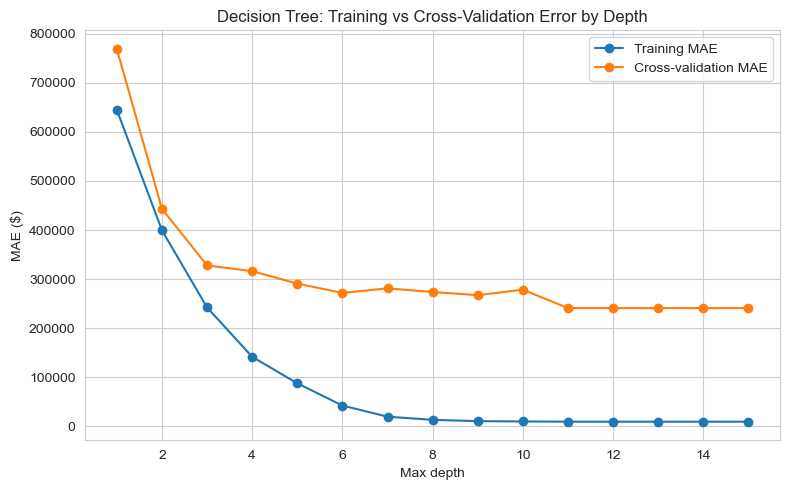

In [22]:
depths = list(range(1, 16))
depth_kf =KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
depth_rows =[]

for depth in depths:
    train_maes, val_maes = [], []
    for train_idx, val_idx in depth_kf.split(xtrain):
        xf_train, xf_val=xtrain.iloc[train_idx], xtrain.iloc[val_idx]
        yf_train_log=ytrain_log.iloc[train_idx]
        yf_train_dollars =ytrain.iloc[train_idx]
        yf_val_dollars =ytrain.iloc[val_idx]

        pipe = Pipeline([('prep', preprocess),('model',DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=depth))])
        pipe.fit(xf_train,yf_train_log)

        train_pred =np.expm1(pipe.predict(xf_train))
        val_pred =np.expm1(pipe.predict(xf_val))

        train_maes.append(mean_absolute_error(yf_train_dollars, train_pred))
        val_maes.append(mean_absolute_error(yf_val_dollars, val_pred))
    depth_rows.append([depth, np.mean(train_maes), np.mean(val_maes)])

depth_table=pd.DataFrame(depth_rows,columns=['max_depth', 'Train MAE', 'CV MAE'])
print(depth_table.to_string(index=False))

plt.figure(figsize=(8,5))
plt.plot(depth_table['max_depth'], depth_table['Train MAE'], marker='o', label='Training MAE')
plt.plot(depth_table['max_depth'], depth_table['CV MAE'], marker='o', label='Cross-validation MAE')
plt.title('Decision Tree: Training vs Cross-Validation Error by Depth')
plt.xlabel('Max depth')
plt.ylabel('MAE ($)')
plt.legend()
plt.tight_layout()
plt.show()

### Result

This is a textbook underfitting/overfitting pattern:

- At **depth 1–2**, both training error and CV error are high and close together — the tree is too simple to capture the patterns in the data (**underfitting**).
- Around **depth 5–6**, CV error reaches close to its lowest point, while training error is already much lower than CV error — a small, healthy, expected gap.
- From **depth 7 onward**, training error keeps shrinking all the way down to almost \$9,500 this is **overfitting**: the tree is learning noise in the training data that does not generalise.

The lowest CV MAE technically appears around depth 11, but the improvement over depth 5–6 is small, and a depth-11 tree has clearly memorised the training data (train MAE near \$9,500). We chose **max_depth = 6** for our final Decision Tree — it sits right at the point where cross-validation error levels off, without the extreme overfitting.
### Discussion — tuning the Random Forest

Random Forest has two simple settings we can tune: the number of trees (`n_estimators`) and the max depth of each tree. We try a small, sensible grid rather than an exhaustive search.


In [23]:
forest_grid_results =[]
for n_estimators in [100,300]:
    for max_depth in [5,10, None]:
        fold_maes =[]
        for train_idx, val_idx in depth_kf.split(xtrain):
            xf_train, xf_val =xtrain.iloc[train_idx],xtrain.iloc[val_idx]
            yf_train_log =ytrain_log.iloc[train_idx]
            yf_val_dollars =ytrain.iloc[val_idx]

            pipe =Pipeline([('prep',preprocess),('model',RandomForestRegressor(
                random_state=RANDOM_STATE, n_estimators=n_estimators, max_depth=max_depth))])
            pipe.fit(xf_train, yf_train_log)
            val_pred =np.expm1(pipe.predict(xf_val))
            fold_maes.append(mean_absolute_error(yf_val_dollars, val_pred))
        forest_grid_results.append([n_estimators, max_depth, np.mean(fold_maes)])

forest_grid_table =pd.DataFrame(forest_grid_results, columns=['n_estimators','max_depth','CV MAE'])
print(forest_grid_table.to_string(index=False))


 n_estimators  max_depth        CV MAE
          100        5.0 234608.246824
          100       10.0 225563.908398
          100        NaN 224294.528390
          300        5.0 235725.677095
          300       10.0 228830.390242
          300        NaN 228080.923273


### Result

The best scoring combination in our small grid is 100 trees with no depth limit (CV MAE ≈ 224,300 dollars), but 100 trees with max depth 10 the setting we already used for forest_model above scores almost identically (≈ 225,600 dollars, a difference of about $1,300). We keep the depth 10 limit anyway: it keeps individual trees a little more conservative on a dataset this small, at essentially no cost to accuracy. Adding more trees (300) did not meaningfully improve results either  it mostly just used more computation for a very similar score. This makes sense: with only 84 training rows, there is a limit to how much extra "wisdom of the crowd" more trees can add.

### Discussion — feature importance

Now that the models are trained, we check which features they actually relied on most, and compare this to our Part 2 expectation (suburb, property type, bedrooms).

                     feature  importance
               num__bedrooms    0.397142
          cat__suburb_Mosman    0.367086
         size__land_size_sqm    0.084386
    cat__suburb_Campbelltown    0.023422
      cat__suburb_Parramatta    0.022771
             bin__size_known    0.022420
             num__car_spaces    0.019582
              num__bathrooms    0.016918
          bin__atypical_sale    0.013513
     cat__property_type_Unit    0.011205
        size__floor_area_sqm    0.011032
    cat__property_type_House    0.007015
cat__property_type_Townhouse    0.002051
              num__sale_year    0.001403
          bin__tenanted_sale    0.000054


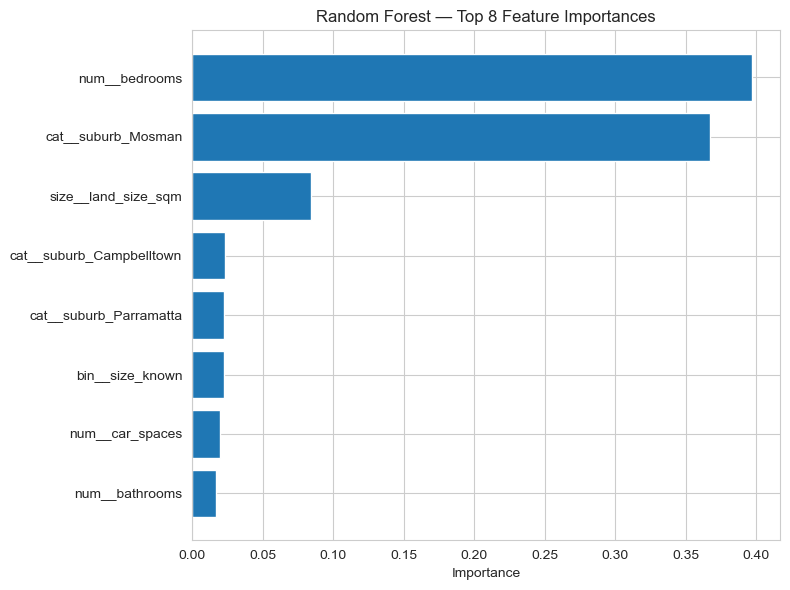

In [24]:
feature_names = fitted_pipes['Random Forest'].named_steps['prep'].get_feature_names_out()

rf_importances =pd.DataFrame({
    'feature': feature_names,
    'importance': fitted_pipes['Random Forest'].named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

print(rf_importances.to_string(index=False))

plt.figure(figsize=(8,6))
plt.barh(rf_importances['feature'][:8][::-1], rf_importances['importance'][:8][::-1])
plt.title('Random Forest — Top 8 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Result

The Random Forest confirms two of our three expected variables very clearly: **bedrooms** and **being in Mosman (suburb_Mosman)** are by far the two most important features, together making up over 75% of the model's total importance. `land_size_sqm` comes in a clear third. `floor_area_sqm` ranks much lower which makes sense, since no House in our data has a recorded floor area at all, and for the property types that do have it, suburb and bedrooms already explain most of the price difference.

`property_type`, our third expected variable, turns out to matter less than we thought **once suburb and bedrooms are already known** this makes some sense, since bedrooms and suburb already capture a lot of the size/price-tier information that property type would otherwise add. This is a good example of the assignment's point about revisiting expectations: our reasoning for choosing property type was sound on its own, but it turned out to be partly redundant with the other two stronger features once the model can use all of them together.

### Discussion — final model recommendation


In [26]:
print('Final comparison (repeated for convenience):')
print(results_table_display.to_string(index=False))

Final comparison (repeated for convenience):
            Model   CV MAE  CV RMSE  CV R2 Test MAE Test RMSE  Test R2
Linear Regression $359,242 $559,378  0.692 $322,149  $472,307    0.906
    Decision Tree $271,885 $427,951  0.802 $258,693  $493,779    0.897
    Random Forest $225,564 $379,177  0.858 $262,865  $562,632    0.866


### Result — recommended model: Random Forest

We recommend the **Random Forest** (100 trees, max depth 10) as the final model

- It has the **lowest cross-validation MAE and RMSE** and the **highest cross-validation R²** of the three models and cross validation is the more trustworthy comparison here, since it is averaged over many folds rather than one small 21 property test set.
- Its test set performance (MAE ≈ 262.9k, R² = 0.87) is close to the Decision Tree's (MAE ≈ $258.7k, R² = 0.90) the small test set gap between the two tree based models is not large enough to overturn what cross validation already told us.
- It is noticeably more stable than a single Decision Tree the depth experiment above showed a single tree can overfit quickly on a dataset this small, while averaging 100 trees reduces that risk.
- Its main downside is being harder to explain than a single tree or a linear equation but the feature importance chart above still gives a genuinely useful, explainable summary of *which* features matter most, even if the exact prediction logic is not a simple rule.

The improvement over Decision Tree is real but modest, not dramatic so in a setting where explainability mattered more than squeezing out the last bit of accuracy, a shallow Decision Tree would be a very reasonable alternative. But given the assignment goal of building the most useful decisionsupport tool, we go with Random Forest.

## Part 4: Investigating Prediction Failures

### Discussion

We now use our final model (Random Forest) on the test set and look closely at the **five properties with the largest prediction errors**. Looking at why a model fails often teaches us more about its limitations than the overall accuracy score does.

In [27]:
best_model =fitted_pipes['Random Forest']
predicted_price =np.expm1(best_model.predict(xtest))

error_table =clean_data.loc[xtest.index, ['address','suburb','property_type','bedrooms','bathrooms','car_spaces','size_sqm','sale_price','notes']].copy()
error_table['predicted_price'] = predicted_price.round(0)
error_table['error'] = (error_table['sale_price']-error_table['predicted_price']).round(0)
error_table['abs_error']=error_table['error'].abs()
error_table =error_table.sort_values('abs_error', ascending=False)

top5_errors =error_table.head(5)
print(top5_errors[['address','suburb','property_type','bedrooms','bathrooms','size_sqm','sale_price','predicted_price','error']].to_string(index=False))

                             address suburb property_type  bedrooms  bathrooms  size_sqm  sale_price  predicted_price     error
      2 Dugald Road, Mosman NSW 2088 Mosman         House         5          3     739.0     7600000        5229299.0 2370701.0
 13/5 The Esplanade, Mosman NSW 2088 Mosman          Unit         1          1       NaN     1450000         774863.0  675137.0
3/701 Military Road, Mosman NSW 2088 Mosman     Townhouse         3          2     237.0     2125000        2549162.0 -424162.0
 3/13 McLeod Street, Mosman NSW 2088 Mosman     Townhouse         3          2     155.6     2080000        2451526.0 -371526.0
     1/30 Hale Road, Mosman NSW 2088 Mosman     Townhouse         3          2     235.0     2180000        2549162.0 -369162.0


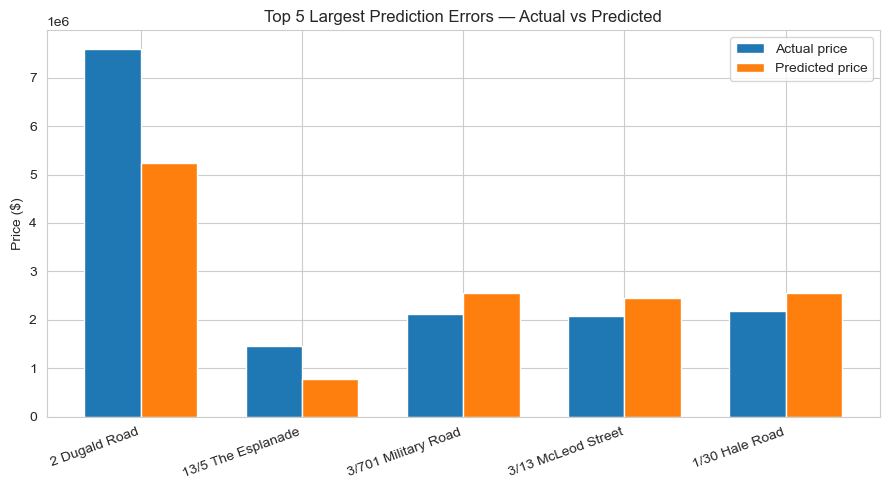

In [30]:
plt.figure(figsize=(9,5))
labels = [a.split(',')[0] for a in top5_errors['address']]
x = np.arange(len(labels))
width = 0.35
plt.bar(x-width/2,top5_errors['sale_price'],width, label='Actual price')
plt.bar(x+width/2,top5_errors['predicted_price'],width,label='Predicted price')
plt.xticks(x, labels, rotation=20, ha='right')
plt.ylabel('Price ($)')
plt.title('Top 5 Largest Prediction Errors — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### Result

**Case 1 — 2 Dugald Road, Mosman (House, 5 bed, 739 sqm land, no floor area recorded)**
- Observed data: actual price AUD 7,600,000, predicted AUD 5,229,299 (underestimated by about AUD 2.36 million).
- Possible explanation: this is the single most expensive property in the entire dataset. Treebased models tend to predict values closer to the "average" of similar training examples.

**Case 2 — 13/5 The Esplanade, Mosman (Unit, 1 bed)**
- Observed data: actual price AUD 1,450,000, predicted AUD 774,863 (underestimated by about AUD 675,000) this property has **no** `land_size_sqm` or `floor_area_sqm` value at all.
- Possible explanation: a 1bedroom unit selling for AUD1.45 million is unusually high for that property type, and the street name ("The Esplanade") suggests a likely waterfront or harbour position but we have no feature that captures views or exact street location.

**Cases 3–5 — three Mosman Townhouses (3 bed, 155–237 sqm land, no floor area recorded, priced AUD 2.08–2.18 million)**
- Observed data: all three were overestimated by the model, by roughly AUD 369,000–AUD 424,000, with two of the three (701 Military Road and 30 Hale Road) receiving the exact same prediction ofAUD 2,549,162.
- Possible explanation is these three appear to be at the more affordable end of Mosman townhouses. The model has learned a fairly high "typical" Mosman price from the houses and other townhouses in the suburb, which may be pulling these predictions upward.

### Discussion — what these failures tell us about the model's limitations

**Every one of the five largest errors is a Mosman property.** This is because Mosman has by far the widest price range of the three suburbs (from ~AUD 700k units to AUD 7.6M houses), so there is more room for the model to be a long way off in dollar terms.

The recurring missing information is **anything related to property *quality* or *view/position within a suburb*** renovation state, exact aspect, water views, street prestige. Our dataset only captures basic structural features (bedrooms, bathrooms, car spaces) two very different properties can look identical to the model.

**When should these predictions be treated cautiously?**
- For very expensive one of a kind properties (like the AUD 7.6M house) — too few similar examples to learn from.
- For properties with missing size information, since the model falls back on a typical value rather than the property's real size.

**Are some property types inherently harder to model?** High value houses and small "boutique" units in expensive suburbs both appear harder to predict than typical mid market properties the former because there are very few extreme comparables because their special features are not captured in the data at all.

## Part 5: Human Judgement, Machine Learning, and Large Language Models

### Discussion

I select 10 properties from our test set (21 properties Part 4 used) and compare three ways of estimating their sale price:

1. **Our machine learning model** (the Random Forest from Part 3).
2. **ChatGPT**, given the same structured property information our model used.
3. **Our own judgement**, formed by looking at comparable sold properties from the training set the way a person without a trained model might approach it.

I chose properties spread across all three suburbs and all three property types, and included the two hardest cases from Part 4 (the AUD7.6M Mosman house and the AUD1.45M Mosman unit) since they are the most interesting test of whether a general purpose LLM or basic human can handle outliers any better than our model did.

**An important design decision: I did not give ChatGPT the street address**, only the same features our model used (suburb, property type, bedrooms, bathrooms, car spaces, land area, distance to CBD). Our ML model was never given the address. it isn't a usable feature for a model, so leaving it out of the LLM prompt keeps this a fair, comparison of what each approach can do with the same information, rather than testing "LLM plus a lookup" against "our model with less information."


In [32]:
ten_addresses = [
    "2 Dugald Road, Mosman NSW 2088", "13/5 The Esplanade, Mosman NSW 2088",
    "3/701 Military Road, Mosman NSW 2088", "41 Lang Street, Mosman NSW 2088",
    "13 Morton Street, Parramatta NSW 2150", "1/77-79 Thomas Street, Parramatta NSW 2150",
    "505/23 Hassall Street, Parramatta NSW 2150", "5 Lachlan Place, Campbelltown NSW 2560",
    "2/51 George Street, Campbelltown NSW 2560", "73/2-10 Tyler Street, Campbelltown NSW 2560",
]
ten_idx=clean_data[clean_data['address'].isin(ten_addresses)].index
ten_idx=xtest.index.intersection(ten_idx)

ten_x =xtest.loc[ten_idx]
ten_ml_pred =np.expm1(fitted_pipes['Random Forest'].predict(ten_x))

comparison =clean_data.loc[ten_idx,['address','suburb','property_type','bedrooms','sale_price']].copy()
comparison['ml_prediction']=ten_ml_pred.round(0)
comparison =comparison.set_index('address').loc[ten_addresses].reset_index()
comparison.insert(0, 'property_no', range(1, 11))
print(comparison.to_string(index=False))

 property_no                                     address       suburb property_type  bedrooms  sale_price  ml_prediction
           1              2 Dugald Road, Mosman NSW 2088       Mosman         House         5     7600000      5229299.0
           2         13/5 The Esplanade, Mosman NSW 2088       Mosman          Unit         1     1450000       774863.0
           3        3/701 Military Road, Mosman NSW 2088       Mosman     Townhouse         3     2125000      2549162.0
           4             41 Lang Street, Mosman NSW 2088       Mosman         House         3     3350000      3586238.0
           5       13 Morton Street, Parramatta NSW 2150   Parramatta         House         4     1800000      1581701.0
           6  1/77-79 Thomas Street, Parramatta NSW 2150   Parramatta     Townhouse         4     1300000      1197949.0
           7  505/23 Hassall Street, Parramatta NSW 2150   Parramatta          Unit         2      660000       596383.0
           8      5 Lachlan Plac

### Result

These are the same 10 properties, numbered 1 to 10 in the order i will use for the rest of Part 5. The Random Forest is off on Property 1 (the AUD7.6M house) and Property 2 (the AUD1.45M unit) same two hard cases already identified in Part 4 and close on most of the midmarket properties (5, 6, 8, 10).

### Discussion — asking ChatGPT

I gave ChatGPT the same 10 properties (numbered identically), using the structured features above and no address, and asked for one price estimate per property. I ran this twice, which turned out to reveal something worth reporting.

**First attempt = web search left on (the default):**

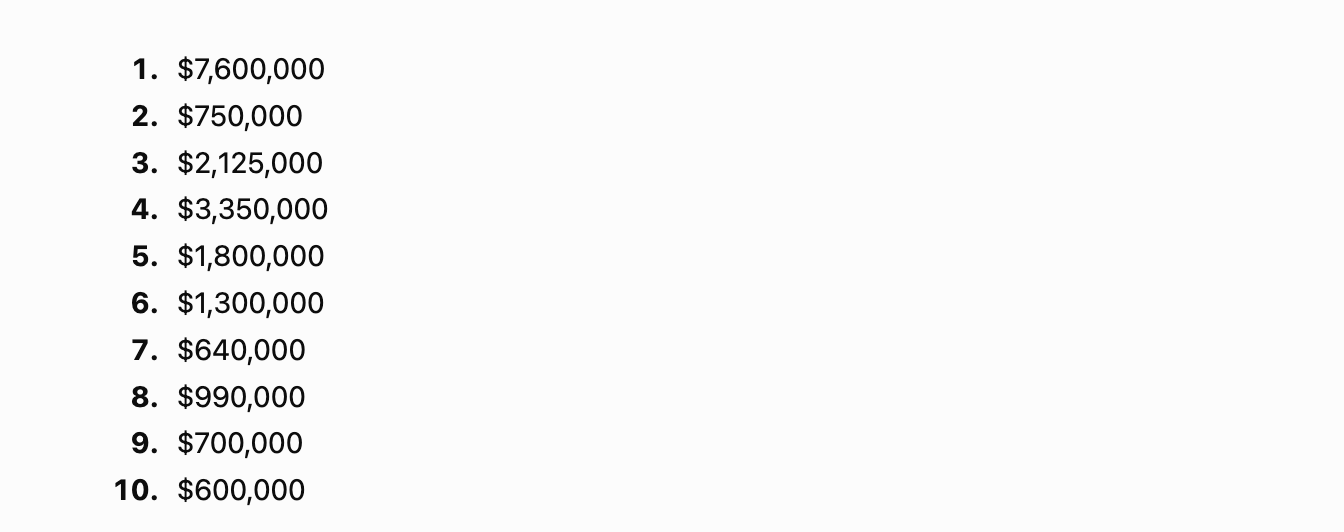

In [33]:
from IPython.display import Image, display
display(Image(filename="With Web search.png"))

**Result:** 6 of these 10 numbers are exact*, match to the real sale price (Properties 1, 3, 4, 5, 6, 8). Genuine price estimation from a handful of structured features essentially never lands on the exact sale price by coincidence our own model, trained directly on the comparable sales, doesn't do this even once. This strongly suggests ChatGPT used its web search access to find the real listings that matched the description, rather than estimating from the property characteristics at all. We treat this as important finding about how LLMs behave when given search access, but not as a fair "estimate" to include in our main comparison.

**Second attempt=web search turned off, asked to estimate from the given characteristics only:**

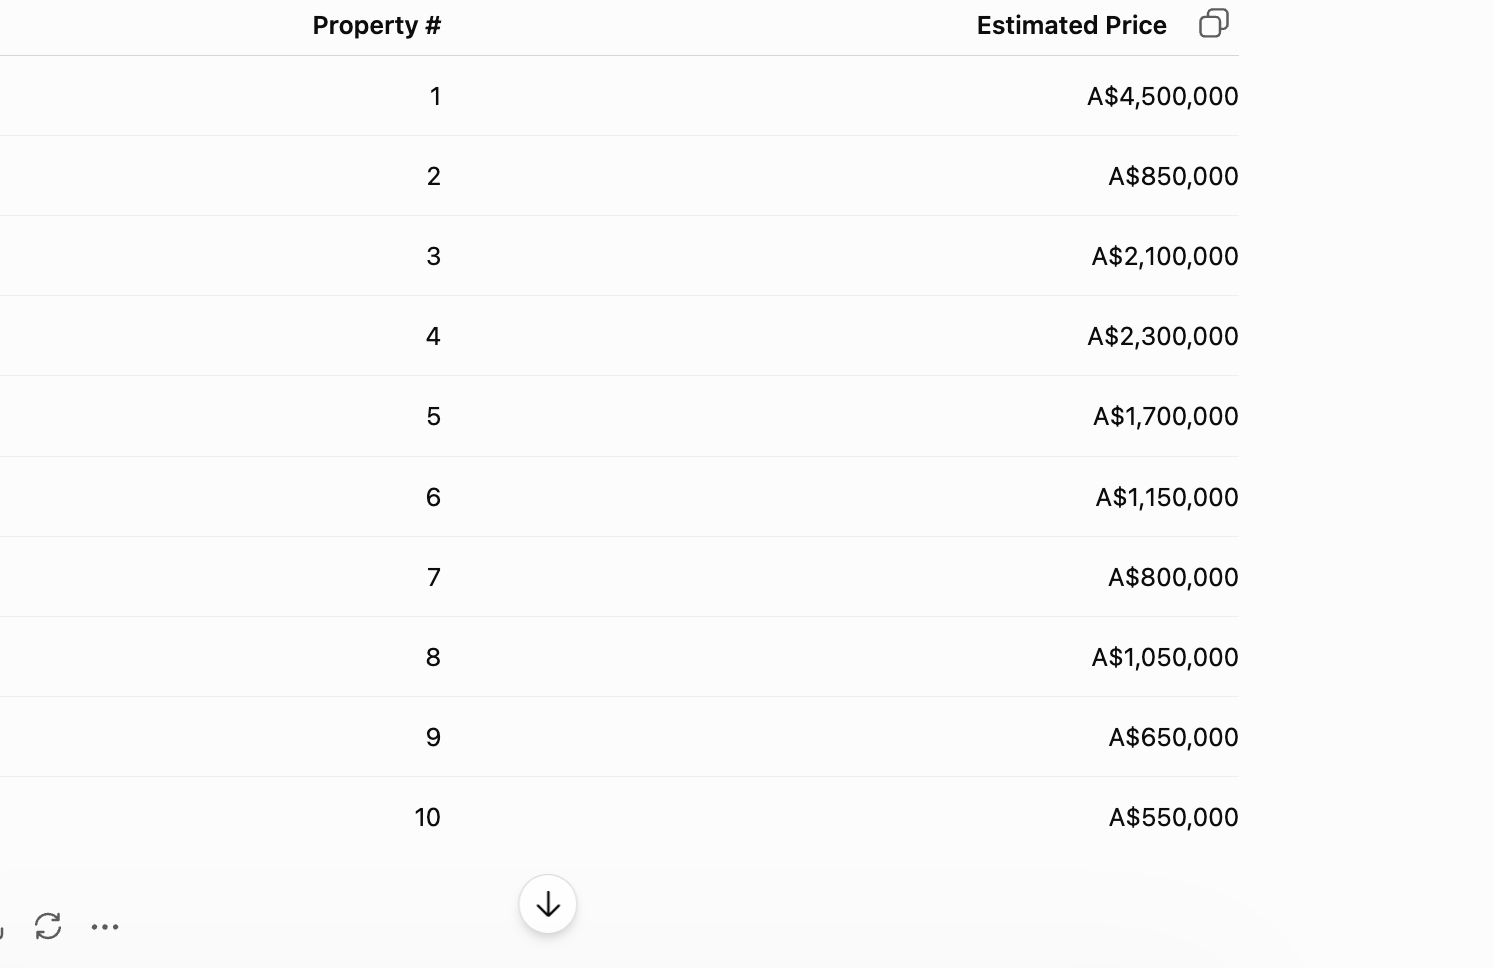

In [34]:
from IPython.display import Image, display
display(Image(filename="Without Web search.png"))

**Result:** with search off, none of the 10 numbers match exactly and the pattern looks like a genuine estimate rather than a lookup this is the version I use in main comparison below.

### Discussion — our own judgement

For our estimate, I did not simply guess a number out of thin air. For each of the 10 properties, I looked at 2–3 comparable sold properties from the training set only , so this is a real human judgement, not one informed by seeing the actual test set prices. For example, for Property 1 (the 5-bedroom Mosman house), the closest training comparables sold for AUD4.4M, AUD5.6M and AUD6.4M — with my judgement estimate for the 10 landing at AUD5,000,000, AUD700,000, AUD1,500,000, AUD2,000,000, AUD1,100,000, AUD1,000,000, AUD500,000, AUD700,000, AUD400,000 and \AUD800,000 respectively.


In [35]:
results = pd.DataFrame({
    'property_no':range(1, 11),
    'address': ten_addresses,
    'actual_price': comparison['sale_price'].values,
    'ml_prediction': comparison['ml_prediction'].values,
    'chatgpt_prediction':[4500000,850000,2100000,2300000, 1700000,1150000,800000, 1050000, 650000, 550000],
    'human_prediction':[5000000,700000, 1500000, 2000000,1100000, 1000000,500000,700000, 400000, 800000],
})

for col in ['ml_prediction', 'chatgpt_prediction','human_prediction']:
    results[col.replace('_prediction','_abs_error')] =(results['actual_price']-results[col]).abs()

print(results[['property_no','actual_price','ml_prediction','chatgpt_prediction','human_prediction']].to_string(index=False))
print()
print('Mean Absolute Error by approach:')
print('  ML model:', round(results['ml_abs_error'].mean()))
print('  ChatGPT (search off):', round(results['chatgpt_abs_error'].mean()))
print('  Human judgement:', round(results['human_abs_error'].mean()))


 property_no  actual_price  ml_prediction  chatgpt_prediction  human_prediction
           1       7600000      5229299.0             4500000           5000000
           2       1450000       774863.0              850000            700000
           3       2125000      2549162.0             2100000           1500000
           4       3350000      3586238.0             2300000           2000000
           5       1800000      1581701.0             1700000           1100000
           6       1300000      1197949.0             1150000           1000000
           7        660000       596383.0              800000            500000
           8        990000      1012067.0             1050000            700000
           9        565000       691715.0              650000            400000
          10        597000       627824.0              550000            800000

Mean Absolute Error by approach:
  ML model: 426981
  ChatGPT (search off): 535700
  Human judgement: 714300


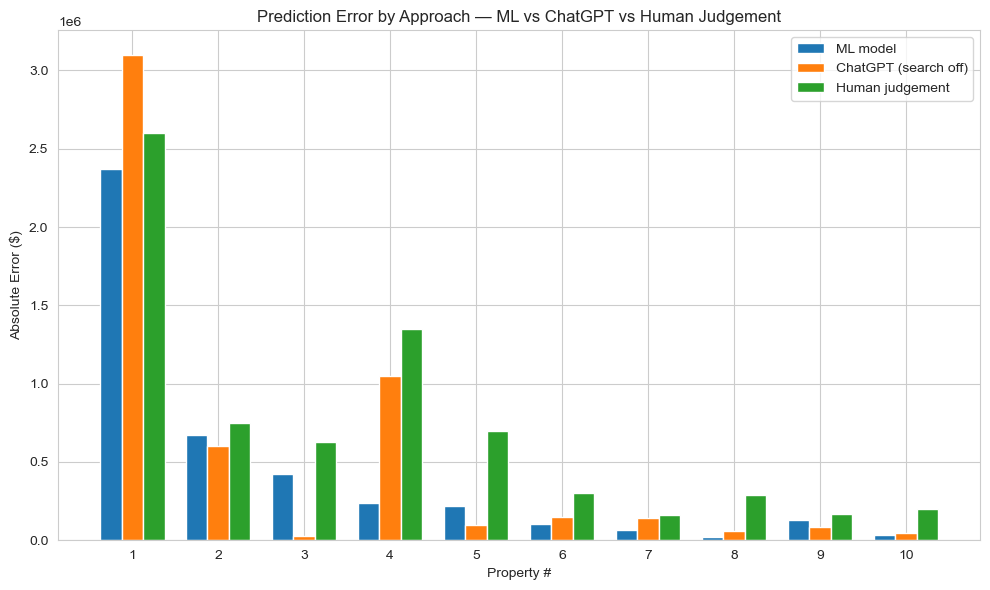

In [37]:
fig, ax =plt.subplots(figsize=(10,6))
x =np.arange(10)
width =0.25
ax.bar(x -width, results['ml_abs_error'], width, label='ML model')
ax.bar(x,results['chatgpt_abs_error'], width,label='ChatGPT (search off)')
ax.bar(x +width, results['human_abs_error'],width, label='Human judgement' )
ax.set_xticks(x)
ax.set_xticklabels(results['property_no'])
ax.set_xlabel('Property #')
ax.set_ylabel('Absolute Error ($)')
ax.set_title('Prediction Error by Approach — ML vs ChatGPT vs Human Judgement')
ax.legend()
plt.tight_layout()
plt.show()


### Result

**Overall accuracy (Mean Absolute Error):** the ML model performed best (≈AUD427,000), ChatGPT with search off was second (≈AUD536,000), and my human judgement was the least accurate of the three (≈AUD714,000).

**Property-by-property winners:** the ML model produced the smallest error on 6 of the 10 properties (1, 4, 6, 7, 8, 10). ChatGPT was the best of the three on the remaining 4 (2, 3, 5, 9). My judgement was not the closest estimate on any single property.

**When did each approach succeed or fail?**
- The **ML model** was most accurate on ordinary, mid market properties close to the training data range (Lachlan Place, Thomas Street, Hassall Street, Tyler Street) exactly where it has the most training examples.
- **ChatGPT** did comparatively well on a couple of properties in the middle of the price range but, like our model, still struggled with the very expensive Mosman house (Property 1) and the priced small unit (Property 2) the same two properties Part 4 already flagged as hard to predict.
- **My own judgement consistently underestimated** — lower than the actual price on 9 of the 10 properties, and by the largest margin on the higher properties (Property 1: AUD2.6M under; Property 4: AUD1.35M under). Looking at only 2–3 comparable sales, without a model's ability to weigh many properties together, appears to undervalue premium properties it is easy to anchor on the lower end of a small set of comparables.

**Does human judgement still add value?** Based on this test, not on raw accuracy alone my guesses were the least accurate of the three approaches here. But two things are worth noting. First, our "human" method used a very quick, minimal effort process a real estate professional with detailed local knowledge would likely do much better. The practical conclusion is that a trained model is strongest for pure numerical accuracy, but rough human intuition without model support is unreliable, particularly at the high end which justifies giving agents a model based estimate rather than a handful of comparables.

**A note on the LLM's web search behaviour:** the gap between our two ChatGPT attempts (MAE ≈AUD536,000 with search off vs unrealistic ≈AUD86,000 with search on, driven by 6 exact matches) is a finding worth highlighting. It shows an LLM "prediction" can come from data retrieval rather than genuine estimation, which isn't obvious unless you specifically control for search access. An LLM based tool that can browse the web is doing something closer to comparable sales lookup than actual predictive modelling, and shouldn't be treated as equivalent to a trained model even if it looks more "accurate."

## Part 6: Final Deployment and Reflection

### How the application was developed

The app was built with **Streamlit**, a python library. We chose it because it is quick to set up and good enough for a simple tool like this.

The app has two files. `model_utils.py` holds the same `SizeImputer` class, feature list, and Random Forest settings used in Part 3 of this notebook. `app.py` builds the actual page: a form asking for suburb, property type, bedrooms, bathrooms, car spaces, and size, and a button that runs the model and shows the predicted price.

## Instructions

1. Extract the provided Zip folder and open its terminal 
2. Install the requirements: `pip install -r requirements.txt`
3. Run the app: `streamlit run app.py`
4. Fill in the property details (suburb, bedrooms, size, etc.)
5. Click "Predict price" to see the estimated sale price

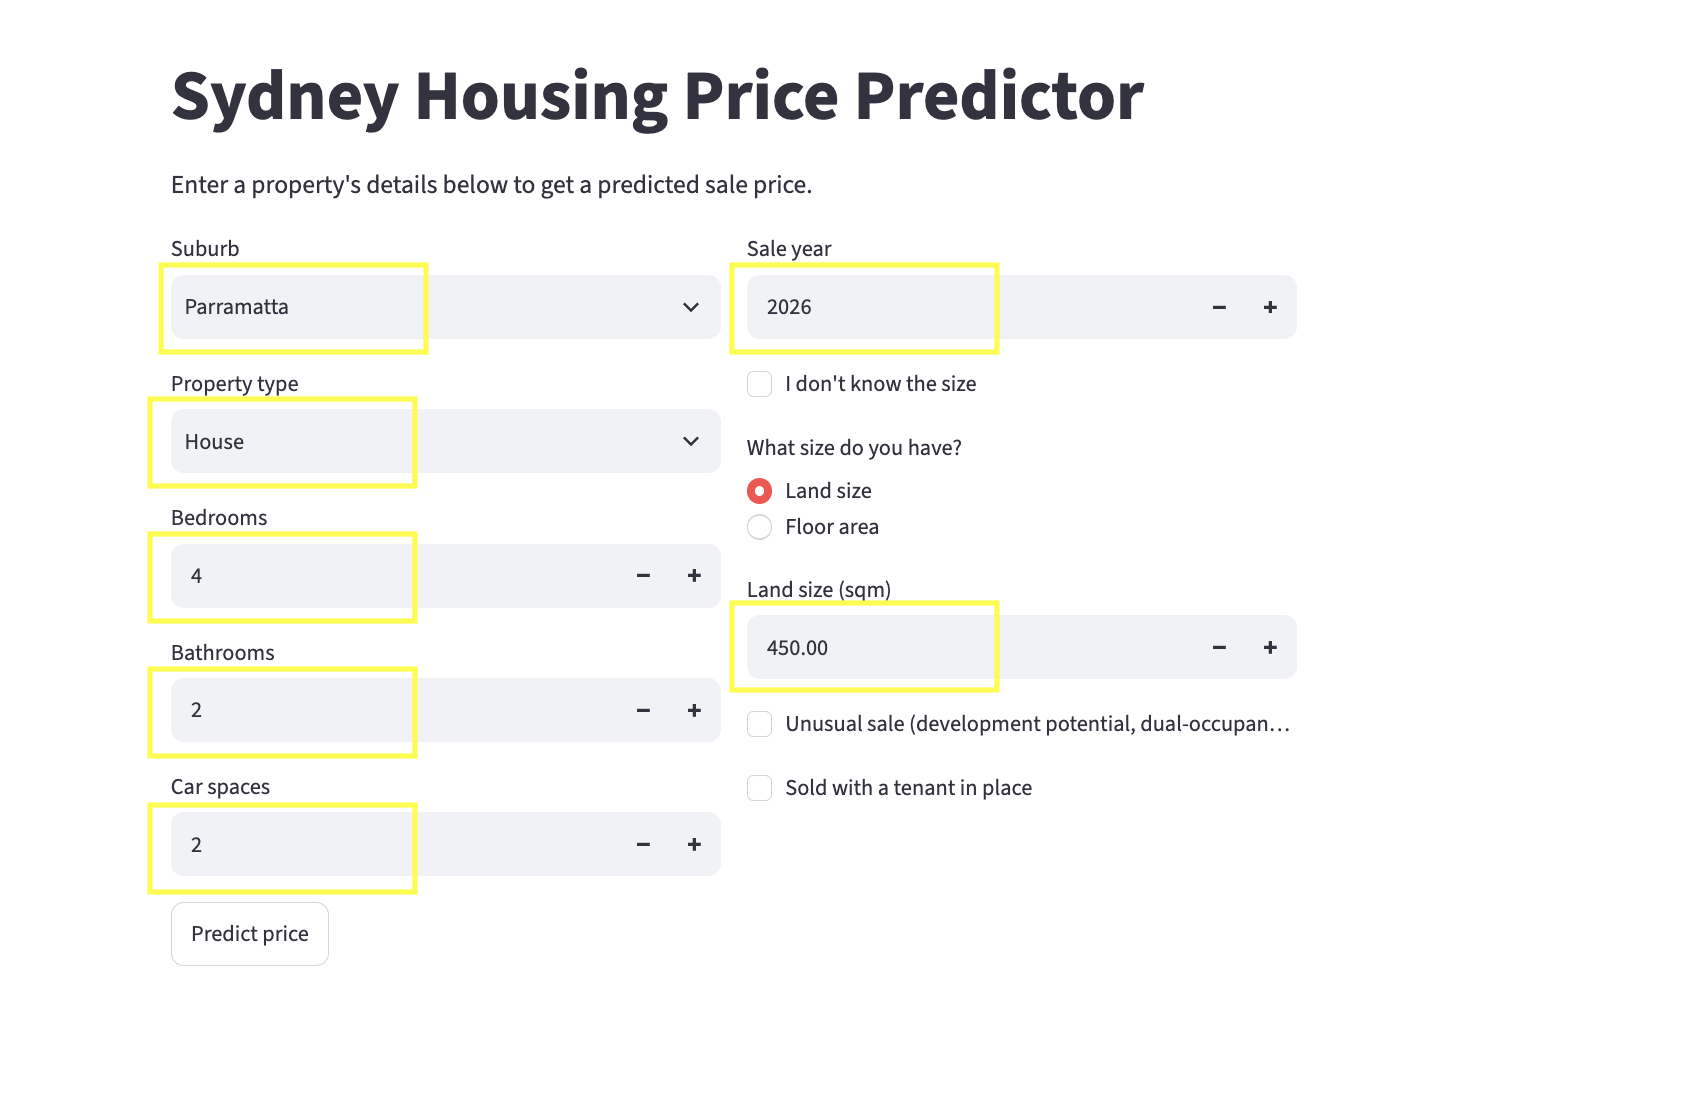

In [38]:
from IPython.display import Image, display
display(Image(filename="app_filled.png"))

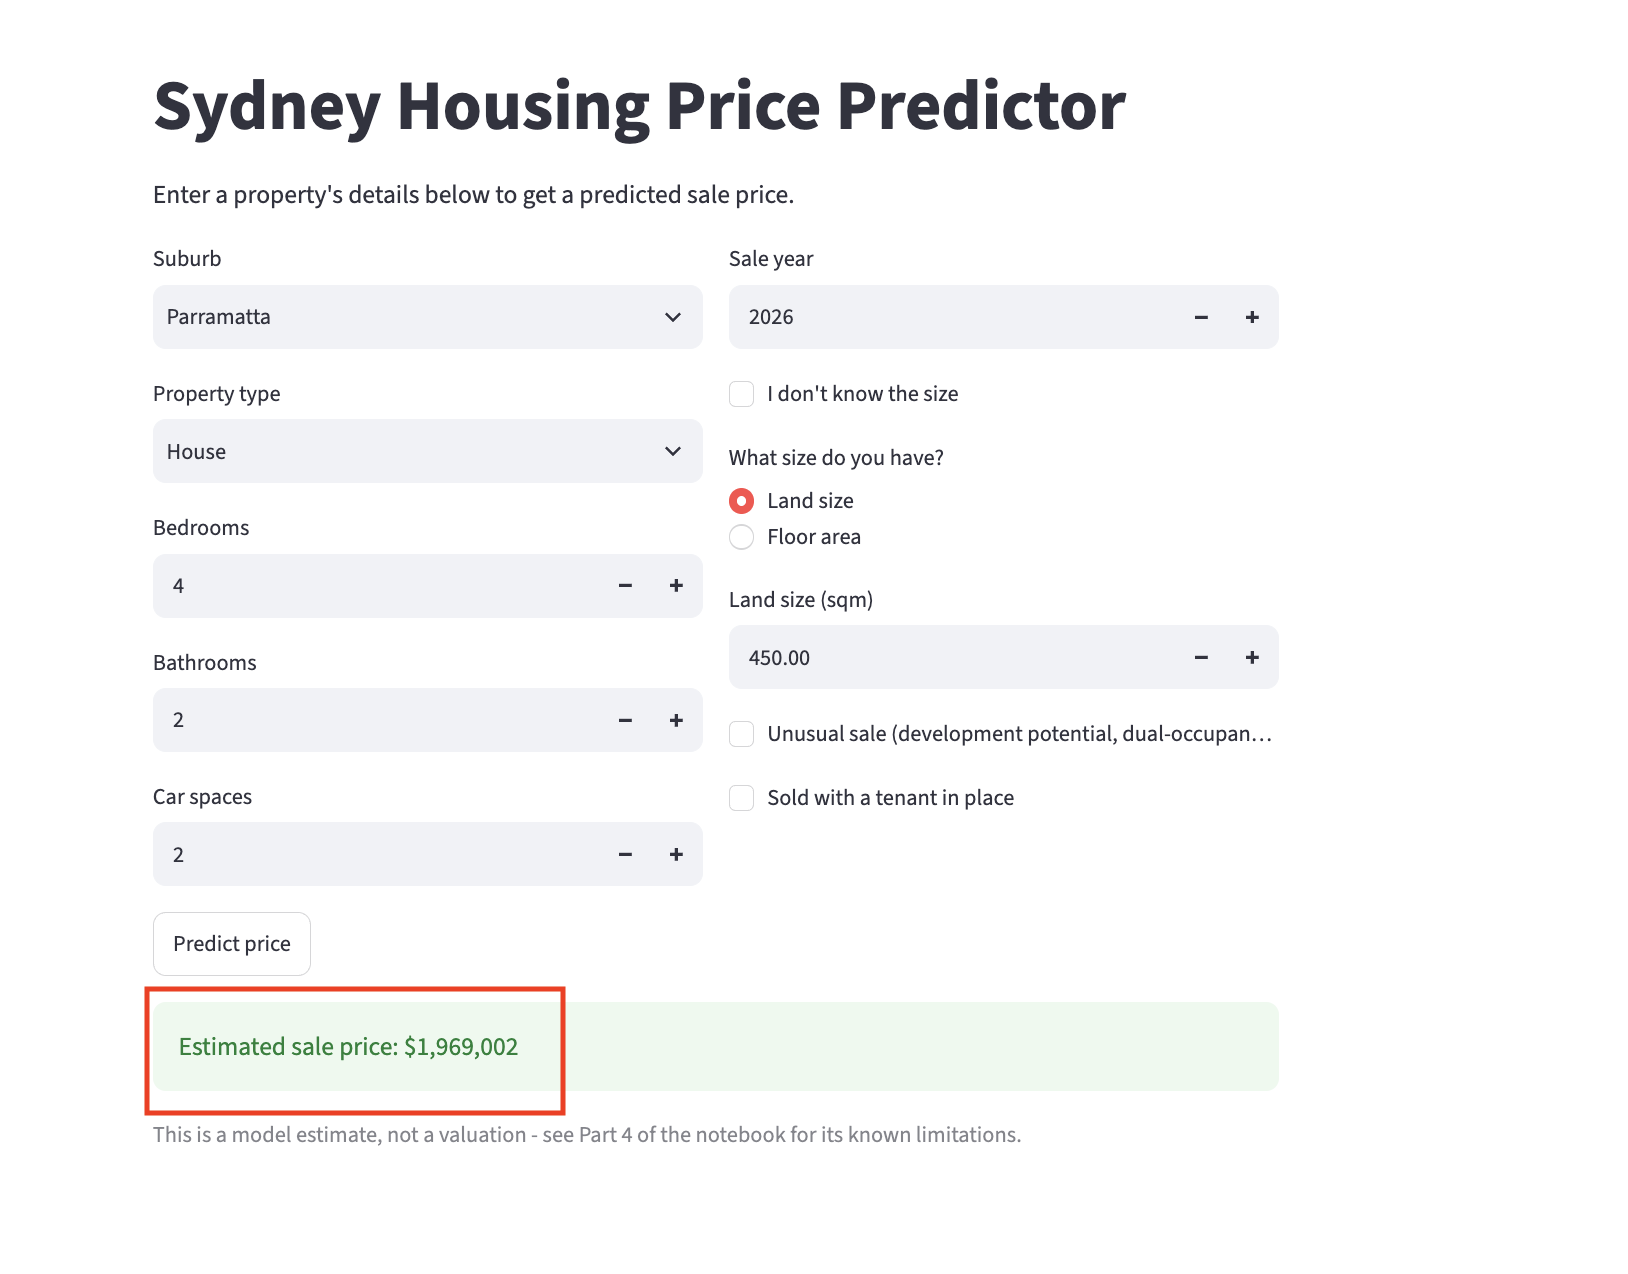

In [39]:
from IPython.display import Image, display
display(Image(filename="app_result.png"))

## Reflection

This project taught us that data collection is often harder than modelling itself. Manually reading listings showed how messy real data can be key fields like year built were missing entirely, and we had to make judgement calls on unusual sales rather than just deleting them.

Feature engineering needed a second attempt: our first method for filling
missing sizes blended two different measurements into one number, giving
unrealistic values. This showed how a careless fix for missing data can
quietly hurt a model.

Model testing showed clear underfitting (Linear Regression) and overfitting a deep Decision Tree), and Random Forest's small accuracy gain over a simpler tree came at the cost of being harder to explain. Deployment brought a different lesson: a model that works on one computer can break on another over library version differences alone.

Ethically, the model leans heavily on suburb, which risks reinforcing
existing price gaps rather than judging each property fairly, and it gives no warning when a prediction is unreliable. With more time or data, we would collect more suburbs, a longer time span, and features like property condition or views.

## References

OpenAI. ChatGPT
— used in Part 5 to generate the LLM price estimates.

Deakin University *Machine Learning Mini Project* unit study materials. CloudDeakin.

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python
— the Python library used to build and evaluate all three regression models.

Domain.com.au. (2026). Sold property listings for Mosman, Parramatta and Campbelltown, NSW
https://www.domain.com.au/

## Project Files

[OneDrive — Project Files](https://deakin365-my.sharepoint.com/:f:/g/personal/s226229264_deakin_edu_au/IgB7VBPrpb5mQ6rmSH39iny7AaDBYWLu-AkwQOY4p-w75hI?e=bGInXN)